In [1]:
uuid_alumno = "ff3f09cc-529b-4011-a745-256ac2565010"

# Sistema RAG Conversacional para Normativa de IA y Protección de Datos

En este cuaderno desarrollo e implemento un asistente conversacional basado en la arquitectura de Generación Aumentada por Recuperación (RAG). El objetivo es que el sistema pueda responder preguntas técnicas y jurídicas complejas sobre el Reglamento General de Protección de Datos (RGPD), las orientaciones sobre Inteligencia Artificial Agéntica y la Opinión 2024/28 del EDPB, citando siempre los artículos y capítulos exactos en lugar de inventar respuestas (alucinaciones).

Durante el desarrollo inicial del proyecto me encontré con dos problemas técnicos habituales cuando se trabaja con textos legales:
1. **Pérdida de contexto en el corte del texto (`chunking`):** Al dividir una ley o reglamento con divisores simples de caracteres o saltos de línea, los párrafos quedaban huérfanos de su encabezado legal. Si el usuario preguntaba por una obligación específica de un artículo, el buscador recuperaba el párrafo pero no sabía a qué artículo ni capítulo pertenecía.
2. **Preguntas generales o fuera de dominio que saturaban la búsqueda documental:** Cuando el usuario saludaba o hacía una pregunta general que no requería consultar la base legal, un RAG clásico intentaba buscar en los documentos legales de todas formas, devolviendo ruido o respuestas confusas.

Para solucionar estos problemas y lograr un funcionamiento fiable, he ido iterando y estructurando el proyecto en 5 decisiones técnicas clave que se implementan paso a paso en este código:

### Decisiones Técnicas Implementadas
- **Corte Jerárquico por Cabeceras Markdown (`MarkdownHeaderTextSplitter`):** Antes de dividir el texto por tamaño, hago una primera pasada que detecta los títulos (`#`), capítulos (`##`) y artículos (`###`) de las leyes y los inyecta como metadatos en cada bloque de texto. De esta forma, cada fragmento conserva su trazabilidad jurídica completa.
- **Búsqueda Híbrida con Diversidad (MMR - Maximal Marginal Relevance):** En vez de devolver simplemente los 4 fragmentos con mayor similitud de coseno (que muchas veces son párrafos repetidos del mismo artículo), utilizo el algoritmo MMR para garantizar que los fragmentos recuperados cubran distintas secciones relevantes del corpus legal.
- **Enrutado Semántico Condicional (`Router` con LangGraph):** Implemento un nodo clasificador con temperatura 0.0 que evalúa cada pregunta del usuario antes de buscar en la base legal. Si la consulta es sobre normativa, la envía al flujo RAG. Si es una conversación general o un saludo, la responde directamente el modelo de lenguaje. Si es una consulta fuera del ámbito del sistema (por ejemplo, mecánica o cocina), la bloquea cortésmente y sin gastar recursos del buscador.
- **Reescritura Contextual de Consultas (`Query Rewriter`):** Si una pregunta legal es poco precisa o depende de turnos anteriores del chat, un nodo intermedio reformula la consulta en una frase autónoma y optimizada antes de lanzarla a la base de datos vectorial.
- **Persistencia Conversacional en Memoria (`MemorySaver` + reductor `add_messages`):** Para que el asistente mantenga una conversación fluida en múltiples turnos, utilizo el checkpointer de LangGraph con un reductor de lista `add_messages` que gestiona el historial sin sobrescribir los turnos anteriores.


In [2]:
# Importacion de librerias requeridas para el motor RAG conversacional
import os
import time
import re
from typing import List, Dict, Any
from typing_extensions import TypedDict

from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import MarkdownHeaderTextSplitter, RecursiveCharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings, ChatGoogleGenerativeAI
from langchain_chroma import Chroma
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, BaseMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
import uuid

# Herramientas de renderizado visual en Jupyter Notebook
from IPython.display import display, Markdown, HTML

# Carga automática de .env si existe en el directorio raíz
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

# Verificacion de la clave de acceso a la API de Gemini
api_key = os.getenv("GEMINI_API_KEY")
if not api_key:
    raise ValueError("[ERROR CRITICO]: No se ha detectado la clave GEMINI_API_KEY en las variables de entorno. Por favor, configurala antes de ejecutar el cuaderno.")
else:
    print("[INFO] Clave GEMINI_API_KEY detectada correctamente en el entorno de ejecucion.")


C:\Users\andre\AppData\Local\Temp\ipykernel_10192\1689121126.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


[INFO] Clave GEMINI_API_KEY detectada correctamente en el entorno de ejecucion.


## 1. Carga del Corpus Normativo

El primer paso consiste en cargar los textos normativos en memoria desde la carpeta `data/raw/`. Como este cuaderno está ubicado en la subcarpeta `notebooks/`, utilizamos `os.path.join("..", "data", "raw")` para retroceder un nivel de directorio de manera limpia y compatible con cualquier sistema operativo.

Los tres documentos normativos que componen la base de conocimiento del proyecto son:
1. `EDPB_Opinion_2024_28.md`: Opinión del Comité Europeo de Protección de Datos sobre el uso de tecnologías de IA.
2. `Orientaciones Ia Agéntica.md`: Guía técnica sobre el despliegue de agentes autónomos y control humano.
3. `reglamentoRGPD.md`: Texto procesado en Markdown del Reglamento General de Protección de Datos europeo.


In [3]:
# Carga de documentos desde la carpeta data/raw usando rutas relativas
# Como el cuaderno se encuentra en la subcarpeta /notebooks, retrocedemos un directorio con '..'
ruta_raw = os.path.join("..", "data", "raw")

archivos_md = [
    "EDPB_Opinion_2024_28.md",
    "Orientaciones Ia Agéntica.md",
    "reglamentoRGPD.md"
]

documentos_crudos = []
print("Cargando archivos normativos desde data/raw/:")
print(f"{'Archivo':<35} | {'Tamaño (KB)':<12} | {'Caracteres':<12}")
print("-" * 65)

for archivo in archivos_md:
    ruta_completa = os.path.join(ruta_raw, archivo)
    if not os.path.exists(ruta_completa):
        raise FileNotFoundError(f"No se encuentra el archivo {archivo} en {ruta_raw}. Verifica que estés ejecutando el cuaderno desde la carpeta notebooks.")
    
    loader = TextLoader(ruta_completa, encoding="utf-8")
    docs = loader.load()
    documentos_crudos.extend(docs)
    
    tamano_kb = os.path.getsize(ruta_completa) / 1024
    num_caracteres = len(docs[0].page_content)
    print(f"{archivo:<35} | {tamano_kb:<12.2f} | {num_caracteres:<12}")

print("-" * 65)
print(f"Carga completada. Total de documentos procesados: {len(documentos_crudos)}")


Cargando archivos normativos desde data/raw/:
Archivo                             | Tamaño (KB)  | Caracteres  
-----------------------------------------------------------------
EDPB_Opinion_2024_28.md             | 93.83        | 96079       
Orientaciones Ia Agéntica.md        | 41.74        | 42085       
reglamentoRGPD.md                   | 388.82       | 388886      
-----------------------------------------------------------------
Carga completada. Total de documentos procesados: 3


## 2. Segmentación del Texto

Aquí implemento el proceso de corte en dos etapas para preservar la estructura legal:

1. **Etapa de división estructural (`MarkdownHeaderTextSplitter`):** Configuramos el divisor para reconocer las cabeceras `#` como `Titulo_Ley`, `##` como `Capitulo` y `###` como `Articulo`. Al mantener el parámetro `strip_headers=False`, el encabezado permanece también en el texto del bloque para reforzar la coincidencia semántica durante la búsqueda de embeddings.
2. **Etapa de división por tamaño (`RecursiveCharacterTextSplitter`):** Los bloques resultantes de la primera etapa se dividen en trozos de hasta 1000 caracteres con un solapamiento de 150 caracteres para no cortar frases a la mitad. Configuramos los separadores priorizando los saltos de párrafo dobles y simples (`\n\n`, `\n`) para evitar generar fragmentos mal formados que puedan causar errores de sintaxis en el archivo JSON del cuaderno al guardarse.


In [4]:
# Etapa 1: División estructural por encabezados Markdown para preservar la jerarquía
headers_to_split_on = [
    ("#", "Titulo_Ley"),
    ("##", "Capitulo"),
    ("###", "Articulo"),
]

md_splitter = MarkdownHeaderTextSplitter(
    headers_to_split_on=headers_to_split_on,
    strip_headers=False  # Mantenemos las cabeceras en el texto para ayudar a la similitud semántica
)

chunks_estructurales = []
for doc in documentos_crudos:
    splits = md_splitter.split_text(doc.page_content)
    for s in splits:
        # Aseguramos un nombre de archivo limpio en los metadatos del fragmento
        s.metadata["source"] = os.path.basename(doc.metadata.get("source", "desconocido"))
    chunks_estructurales.extend(splits)

# Etapa 2: Corte de bloques largos limitando a 1000 caracteres
char_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=150,
    separators=["\n\n", "\n", ". ", " ", ""]
)

chunks_finales = char_splitter.split_documents(chunks_estructurales)

print("Resumen del proceso de segmentación:")
print(f" - Bloques tras corte estructural por cabeceras: {len(chunks_estructurales)}")
print(f" - Trozos finales listos para indexar: {len(chunks_finales)}")
print("-" * 65)
print("Muestra de metadatos jerárquicos extraídos en un fragmento de control:")
muestra_idx = min(50, len(chunks_finales) - 1)
for clave, valor in chunks_finales[muestra_idx].metadata.items():
    print(f"   * {clave}: {valor}")


Resumen del proceso de segmentación:
 - Bloques tras corte estructural por cabeceras: 293
 - Trozos finales listos para indexar: 903
-----------------------------------------------------------------
Muestra de metadatos jerárquicos extraídos en un fragmento de control:
   * Titulo_Ley: **Opinion 28/2024 on certain data protection aspects related to the processing of personal data in the context of AI models**
   * Capitulo: **3 On the merits of the request**
   * Articulo: **3.1 On the nature of AI models in relation to the definition of personal data**
   * source: EDPB_Opinion_2024_28.md


## 3. Indexación Vectorial

Una vez segmentados y enriquecidos los fragmentos con su jerarquía, procedemos a generar sus representaciones vectoriales (embeddings) y almacenarlos en una base de datos local con ChromaDB en el directorio `vector_db/`.

Para el cálculo de los vectores utilizo el modelo `models/gemini-embedding-001` de Google. Para hacer la carga robusta frente a los límites diarios o por minuto de la API gratuita (error HTTP 429 de límite de cuota), implemento un control en lotes de 15 documentos con reintentos automáticos y pausas de seguridad. Si el sistema detecta que la base de datos ya existe en el disco, carga los vectores directamente en memoria omitiendo las llamadas a la API para ahorrar tiempo y cuota.


In [5]:
# Configuración del modelo de embeddings de Gemini
embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",
    google_api_key=api_key
)

# Definición de la ruta al directorio persistente local ../vector_db
ruta_chroma = os.path.join("..", "vector_db")
vectorstore = Chroma(
    collection_name="corpus_normativo_v3",
    embedding_function=embeddings,
    persist_directory=ruta_chroma
)

# Control condicional para evitar gastar cuota si la base de datos ya existe en disco
forzar_reindexacion = False  # Cambiar a True solo si se editan los archivos crudos en data/raw/
vectores_existentes = vectorstore._collection.count()

if vectores_existentes > 0 and not forzar_reindexacion:
    print(f"Base de datos vectorial detectada en disco ({ruta_chroma}).")
    print(f"Se han cargado directamente {vectores_existentes} vectores en memoria.")
    print("Omite la reindexación para ahorrar tiempo y peticiones a la API.")
else:
    if forzar_reindexacion and vectores_existentes > 0:
        print("Limpiando colección anterior en ChromaDB para reindexar...")
        vectorstore.delete_collection()
        vectorstore = Chroma(
            collection_name="corpus_normativo_v3",
            embedding_function=embeddings,
            persist_directory=ruta_chroma
        )
    
    print("Iniciando indexación en lotes controlados para respetar los límites de la API...")
    t_inicio = time.time()
    
    batch_size = 15  # Procesamos en bloques pequeños de 15 trozos
    for i in range(0, len(chunks_finales), batch_size):
        lote = chunks_finales[i : i + batch_size]
        reintentos = 0
        max_reintentos = 3
        
        while reintentos <= max_reintentos:
            try:
                vectorstore.add_documents(lote)
                break
            except Exception as e:
                reintentos += 1
                if reintentos > max_reintentos:
                    print(f"Error de indexación en el lote {i} tras {max_reintentos} intentos: {e}")
                    raise e
                
                # Si Google devuelve error 429 de límite de peticiones, esperamos 65 segundos antes de reintentar
                tiempo_espera = 65.0
                print(f"Aviso de límite de peticiones ({e}). Pausando {tiempo_espera}s antes del reintento {reintentos}/{max_reintentos}...")
                time.sleep(tiempo_espera)
        
        # Pausa ligera entre lotes para mantener un flujo constante y seguro
        time.sleep(2.0)
    
    t_total = time.time() - t_inicio
    print(f"Indexación completada. {len(chunks_finales)} vectores indexados en {t_total:.2f} segundos.")


Base de datos vectorial detectada en disco (..\vector_db).
Se han cargado directamente 903 vectores en memoria.
Omite la reindexación para ahorrar tiempo y peticiones a la API.


## 4. Verificación Aislada de la Búsqueda Vectorial

Before de construir el grafo conversacional y conectar el modelo de lenguaje, conviene hacer una prueba unitaria del buscador para asegurarnos de que la base de datos vectorial funciona en crudo. Lanzamos una consulta de control con `similarity_search` pidiendo los 2 fragmentos más cercanos y verificamos en la consola que los metadatos (`Titulo_Ley`, `Capitulo`, `Articulo`) se recuperan correctamente junto al texto.


In [6]:
# Prueba unitaria del buscador vectorial (Retriever en crudo)
consulta_test = "¿En qué condiciones es lícito el tratamiento de datos personales según el RGPD y qué papel juega el consentimiento?"
print("Ejecutando búsqueda vectorial unitaria de control (top_k=2)...")
print(f"Consulta: '{consulta_test}'\n" + "="*75)

resultados_test = vectorstore.similarity_search(consulta_test, k=2)

if resultados_test:
    for idx, doc in enumerate(resultados_test, 1):
        fuente = doc.metadata.get("source", "desconocido")
        titulo = doc.metadata.get("Titulo_Ley", "")
        capitulo = doc.metadata.get("Capitulo", "")
        articulo = doc.metadata.get("Articulo", "")
        jerarquia = f"{titulo} -> {capitulo} -> {articulo}".strip(" ->")
        
        print(f"\n[Resultado #{idx}] Archivo: {fuente} | Jerarquía: [{jerarquia}]")
        print("Extracto (primeros 250 caracteres):")
        print("-" * 75)
        print(doc.page_content[:250].replace("\n", " ") + "...")
        print("-" * 75)
    print("\nLa base vectorial responde correctamente conservando la trazabilidad jerárquica.")
else:
    print("Error: No se obtuvieron resultados en la prueba unitaria del buscador.")


Ejecutando búsqueda vectorial unitaria de control (top_k=2)...
Consulta: '¿En qué condiciones es lícito el tratamiento de datos personales según el RGPD y qué papel juega el consentimiento?'

[Resultado #1] Archivo: reglamentoRGPD.md | Jerarquía: [REGLAMENTOS -> **de 27 de abril de 2016**]
Extracto (primeros 250 caracteres):
---------------------------------------------------------------------------
- (40) Para que el tratamiento sea lícito, los datos personales deben ser tratados con el consentimiento del interesado o sobre alguna otra base legítima establecida conforme a Derecho, ya sea en el presente Reglamento o en virtud de   <u>ES</u>   ot...
---------------------------------------------------------------------------

[Resultado #2] Archivo: reglamentoRGPD.md | Jerarquía: [REGLAMENTOS -> **de 27 de abril de 2016**]
Extracto (primeros 250 caracteres):
---------------------------------------------------------------------------
- (43) Para garantizar que el consentimiento se haya da

## 5. Construcción del Grafo

En esta sección estructuro el flujo de ejecución mediante una máquina de estados conversacional (`StateGraph`). La lógica de control se divide en funciones y nodos especializados:

- **Nodo `router_node` (Enrutador Semántico):** Analiza la pregunta entrante usando `models/gemini-2.5-flash` con temperatura `0.0` y la clasifica exactamente en una de tres categorías: `LEGAL_RAG` (consultas sobre normativa legal o técnica de IA), `GENERAL_LLM` (saludos, agradecimientos o conversación general) o `OUT_OF_DOMAIN` (preguntas de cocina, mecánica, deportes u otros temas fuera de contexto).
- **Nodo `rewrite_query_node` (Reescritor):** Si la consulta es de tipo `LEGAL_RAG`, analiza los turnos anteriores del chat y reformula la pregunta para que sea completamente autodescriptiva, eliminando ambigüedades como pronombres o referencias implícitas.
- **Nodo `retrieve_node` (Buscador MMR):** Utiliza `max_marginal_relevance_search` con `k=4` y `fetch_k=20` para obtener 4 fragmentos legales muy relevantes y al mismo tiempo diversos entre sí.
- **Nodo `generate_node` (Generador Legal):** Construye un prompt detallado que incluye el historial reciente y el contexto legal recuperado, indicando claramente la fuente (`source`) y la jerarquía de cada fragmento. El modelo responde citando los artículos y capítulos exactos en los que se apoya.
- **Nodos Directos (`direct_llm_node` y `out_of_domain_node`):** Gestionan respuestas corteses e inmediatas para saludos y preguntas fuera de dominio sin consultar la base vectorial.

Para que la memoria funcione de forma predecible sin que los mensajes antiguos se sobreescriban en cada iteración del grafo, definimos el estado `GraphState` anotando el campo `messages` con el reductor nativo `add_messages` de LangGraph (`Annotated[List[BaseMessage], add_messages]`).


Sistema RAG conversacional (Enrutador + MMR + MemorySaver) compilado en memoria y listo para responder.


### Diagrama de Flujo del Grafo de Estados RAG Conversacional

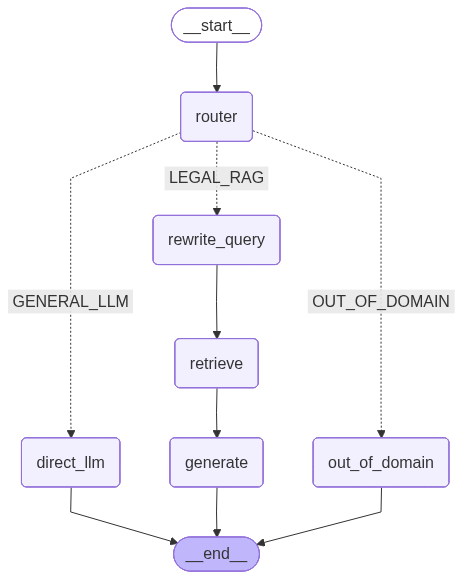

In [ ]:
# Importación explícita para evitar NameError en entornos limpios
from langchain_core.messages import BaseMessage
from typing import Annotated
from langgraph.graph.message import add_messages

# Definicion del estado para el grafo V4 en LangGraph (Con reductor incremental add_messages)
class GraphState(TypedDict, total=False):
    messages: Annotated[List[BaseMessage], add_messages]
    query_reformulada: str
    documentos_recuperados: List[Any]
    intencion: str

# Instanciacion del modelo LLM conversacional agil para V4
llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature=0.2,
    max_tokens=1500,
    max_retries=6,
    google_api_key=api_key
)

# Instanciación del modelo determinista para el router de intención (temperatura 0.0)
llm_router = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature=0.0,
    max_tokens=100,
    max_retries=6,
    google_api_key=api_key
)

# 1. Nodo Enrutador de Intencion (Clasificador determinista de bajo coste)
def router_node(state: GraphState) -> Dict[str, Any]:
    messages = state["messages"]
    ultima_pregunta = messages[-1].content if messages else ""
    prompt_router = f"""Analiza la pregunta del usuario y clasificala exactamente en UNA de las tres opciones siguientes (devuelve UNICAMENTE la palabra clave):
- LEGAL_RAG: Si la consulta versa sobre derecho, normativa, RGPD, articulos, multas, DPO, auditoria de inteligencia artificial, modelos de IA o privacidad europea.
- GENERAL_LLM: Si es un saludo conversacional (ej. 'Hola', 'Buenos dias', 'Que tal') o una pregunta abstracta/informatica de cortesía sin relacion especifica con legislacion europea ni documentos legales concretos.
- OUT_OF_DOMAIN: Si la consulta trata sobre deportes, futbol, recetas de cocina, entretenimiento, o temas ajenos a tecnologia, IA y derecho.

Pregunta: "{ultima_pregunta}"
Clasificacion:"""
    resp = llm_router.invoke([HumanMessage(content=prompt_router)])
    cat_raw = resp.content
    if isinstance(cat_raw, list):
        cat_raw = "".join([b.get("text", "") if isinstance(b, dict) else str(b) for b in cat_raw])
    cat = str(cat_raw).strip()
    if "OUT_OF_DOMAIN" in cat:
        return {"intencion": "OUT_OF_DOMAIN"}
    elif "GENERAL_LLM" in cat:
        return {"intencion": "GENERAL_LLM"}
    else:
        return {"intencion": "LEGAL_RAG"}

# 2. Nodos de respuesta directa (Saludos y Fuera de Dominio con Espejo Lingüístico Impermeable)
def direct_llm_node(state: GraphState) -> Dict[str, Any]:
    messages = state["messages"]
    ultima_pregunta = messages[-1].content if messages else ""
    prompt_direct = f"""[MANDATORY LANGUAGE GUARDRAIL / ESPEJO LINGÜÍSTICO OBLIGATORIO]\n
Detect the exact language of the user's input: "{ultima_pregunta}".\n
You MUST respond 100% in that EXACT same language without mixing languages or repeating prefixes.\n
\n
- SI LA PREGUNTA ESTÁ EN ESPAÑOL:\n
Eres un Consultor Legal y Tecnológico de Alto Nivel. Responde en español de forma profesional, educada y breve a su mensaje o saludo, indicando tu especialidad en cumplimiento del RGPD y auditoría de Inteligencia Artificial Agéntica. No incluyas etiquetas como 'Respuesta:'.\n
\n
- IF THE INPUT IS IN ENGLISH:\n
You are a Senior Legal and Technological Consultant. Respond strictly in English in a professional, polite, and brief manner to their message or greeting, stating your specialization in GDPR compliance and Agentic AI auditing. Do not include labels like 'Response:'.\n
\n
User Input: "{ultima_pregunta}"\n"""
    resp = llm.invoke([HumanMessage(content=prompt_direct)])
    contenido = resp.content
    if isinstance(contenido, list):
        contenido = "".join([b.get("text", "") if isinstance(b, dict) else str(b) for b in contenido])
    contenido = str(contenido).strip()
    return {"messages": messages + [AIMessage(content=contenido)]}

def out_of_domain_node(state: GraphState) -> Dict[str, Any]:
    messages = state["messages"]
    ultima_pregunta = messages[-1].content if messages else ""
    prompt_ood = f"""Detect the exact language of this user query: "{ultima_pregunta}".\n
If the query is in Spanish, output EXACTLY AND ONLY: No estoy entrenado para responder sobre ese tema.\n
If the query is in English, output EXACTLY AND ONLY: I am not trained to answer questions on that topic.\n
Do not output anything else."""
    resp = llm.invoke([HumanMessage(content=prompt_ood)])
    contenido = resp.content
    if isinstance(contenido, list):
        contenido = "".join([b.get("text", "") if isinstance(b, dict) else str(b) for b in contenido])
    contenido = str(contenido).strip()
    return {"messages": messages + [AIMessage(content=contenido)]}

# 3. Nodo Reformulador de Anáforas (Para ruta RAG)
def rewrite_query_node(state: GraphState) -> Dict[str, Any]:
    messages = state["messages"]
    ultima_pregunta = messages[-1].content if messages else ""
    if len(messages) <= 1:
        return {"query_reformulada": ultima_pregunta}
    prompt_reformulacion = f"""Historial reciente del chat:
{[m.content for m in messages[-4:-1]]}

Pregunta actual del usuario: "{ultima_pregunta}"

Tu tarea tecnica es reformular la pregunta actual para que sea independiente y autocontenida, reemplazando pronombres o referencias implicitas por los conceptos de los turnos anteriores. Devuelve unicamente la pregunta reformulada sin preambulos ni explicaciones."""
    respuesta = llm.invoke([HumanMessage(content=prompt_reformulacion)])
    contenido_req = respuesta.content
    if isinstance(contenido_req, list):
        contenido_req = "".join([b.get("text", "") if isinstance(b, dict) else str(b) for b in contenido_req])
    return {"query_reformulada": str(contenido_req).strip()}

# 4. Nodo de Recuperación Híbrida MMR en Dos Etapas
def retrieve_node(state: GraphState) -> Dict[str, Any]:
    query = state.get("query_reformulada") or state["messages"][-1].content
    try:
        retriever = vectorstore.as_retriever(
            search_type="mmr",
            search_kwargs={"k": 4, "fetch_k": 20, "lambda_mult": 0.7}
        )
        docs = retriever.invoke(query)
        return {"documentos_recuperados": docs}
    except Exception as e:
        print(f"[ADVERTENCIA] Error en la consulta vectorial MMR: {e}")
        return {"documentos_recuperados": []}

# 5. Nodo de Generación Legal RAG (Con Guardrails e Instrucción Elástica de Síntesis)
template_rag = """[PERFIL Y TONO]
Eres un Consultor Legal Senior y Arquitecto de Cumplimiento Normativo en Inteligencia Artificial y Privacidad (RGPD / EDPB / IA Agéntica).
Tu lenguaje debe ser formal, preciso, analítico, riguroso y estrictamente acotado al conocimiento normativo facilitado.

[REGLAS DE COMPORTAMIENTO ESTRATEGICO Y GUARDRAILS]
1. Responde UNICAMENTE utilizando la información técnica y normativa presente en los fragmentos de [CONTEXTO DE OPERACION RECUPERADO]. No inventes ni supongas nada fuera de estos textos.
2. Si el usuario hace referencia a una pregunta o respuesta anterior, consulta el [HISTORIAL DE CONVERSACION RECIENTE] para mantener coherencia absoluta.
3. GUARDRAIL DE DOMINIO: Si la pregunta del usuario NO está relacionada en absoluto con el ámbito legal, tecnológico, inteligencia artificial o protección de datos (ej. recetas de cocina, deportes, literatura general), debes responder exactamente: "No estoy entrenado para responder sobre ese tema".
4. GUARDRAIL DE AUSENCIA DE INFORMACION: Si la pregunta está dentro del dominio jurídico/tecnológico, pero la respuesta no se encuentra en los fragmentos recuperados, tu única respuesta debe ser: "La información disponible en la base de conocimientos no permite responder a esta consulta".
5. GUARDRAIL DE IDIOMA (ESPEJO LINGÜÍSTICO OBLIGATORIO): Detecta el idioma en que está escrita la "Pregunta actual del usuario" y redacta tu dictamen SIEMPRE en ese exacto mismo idioma:
   - Si la "Pregunta actual del usuario" está en ESPAÑOL, el 100% de tu respuesta (Conclusión Directa, Análisis Normativo y Trazabilidad Jurídica) DEBE estar estrictamente en ESPAÑOL. Queda terminantemente prohibido usar inglés.
   - Si la "Pregunta actual del usuario" está en INGLÉS, el 100% de tu dictamen DEBE redactarse estrictamente en INGLÉS, traduciendo al inglés cualquier concepto legal de los textos en español.

[FORMATO DE SALIDA OBLIGATORIO Y ESPEJO LINGÜÍSTICO]
Detecta el idioma en que está escrita la "Pregunta actual del usuario". El 100% de tu texto, incluyendo estrictamente los encabezados y el contenido de cada sección, DEBE estar exactamente en el mismo idioma de la pregunta:

- SI LA PREGUNTA ESTÁ EN ESPAÑOL:
  Estructura tu respuesta utilizando estos tres encabezados exactos e inalterados SIN NUMERAR y redacta el contenido en español:
  ### Conclusión Directa
  Una única frase corta, profesional y categórica respondiendo de forma clara e inequívoca a la consulta planteada.
  ### Análisis Normativo
  Explicación técnica detallada y fundamentada en viñetas ordenadas o párrafos breves, basada exclusivamente en los preceptos y considerandos de los fragmentos recuperados.
  ### Trazabilidad Jurídica
  Indica al final de tu respuesta las fuentes exactas de donde extrajiste cada afirmación. REGLA DE DESDUPLICACION OBLIGATORIA: Si varios fragmentos utilizados pertenecen exactamente a la misma ley, capítulo y artículo o sección, agrupa las referencias y escribe esa cabecera UNA SOLA VEZ en la lista final. Está estrictamente prohibido repetir citas legales idénticas. Utiliza viñetas tipográficas limpias con el formato:
  * **<Nombre_Archivo> (<Titulo_Ley> -> <Capitulo> -> <Articulo>)** — Breve mención al precepto.

- SI LA PREGUNTA ESTÁ EN INGLÉS:
  Estructura tu respuesta utilizando estrictamente estos tres encabezados exactos en inglés SIN NUMERAR y TRADUCE COMPLETAMENTE AL INGLÉS todo el dictamen (Conclusión, Análisis Normativo y justificación de las fuentes):
  ### Direct Conclusion
  A single short, professional, and definitive sentence clearly and unequivocally answering the query.
  ### Normative Analysis
  Detailed technical explanation in ordered bullet points or short paragraphs, based exclusively on the provisions and recitals of the retrieved fragments. You must translate all Spanish legal concepts to precise English terminology.
  ### Legal Traceability
  List at the end the exact sources from which each statement was extracted. MANDATORY DEDUPLICATION RULE: If multiple fragments belong to the exact same law, chapter, and article or section, group the references and write that header ONLY ONCE in the final list. Use clean typographic bullets with the format:
  * **<File_Name> (<Law_Title> -> <Chapter> -> <Article>)** — Brief mention of the legal provision translated to English.

[HISTORIAL DE CONVERSACION RECIENTE]
{chat_history}

[CONTEXTO DE OPERACION RECUPERADO]
{context}

Pregunta actual del usuario: 
{question}
"""

def generate_node(state: GraphState) -> Dict[str, Any]:
    messages = state["messages"]
    docs = state.get("documentos_recuperados", [])
    query = state.get("query_reformulada") or messages[-1].content
    if not docs:
        msg_fallo = "La información disponible en la base de conocimientos no permite responder a esta consulta."
        return {"messages": messages + [AIMessage(content=msg_fallo)]}
        
    contexto_estratificado = []
    for d in docs:
        meta = d.metadata
        src = meta.get("source", "Documento Desconocido")
        titulo_ley = meta.get("Titulo_Ley", meta.get("titulo_ley", "General"))
        cap = meta.get("Capitulo", meta.get("capitulo", "Sin Capitulo"))
        art = meta.get("Articulo", meta.get("articulo_o_seccion", "Sin Articulo"))
        jerarquia = f"{titulo_ley} -> {cap} -> {art}"
        contexto_estratificado.append(f"--- DOCUMENTO: {src} | ESTRUCTURA: [{jerarquia}] ---\n{d.page_content}")
        
    texto_contexto = "\n\n".join(contexto_estratificado)
    historial_str = ""
    if len(messages) > 1:
        turnos_recientes = messages[-5:-1] if len(messages) > 5 else messages[:-1]
        for m in turnos_recientes:
            rol = "Usuario" if isinstance(m, HumanMessage) else "Consultor"
            historial_str += f"{rol}: {m.content}\n"
            
    prompt_evaluado = template_rag.format(
        chat_history=historial_str or "Sin historial previo.",
        context=texto_contexto,
        question=query
    )
    respuesta = llm.invoke([HumanMessage(content=prompt_evaluado)])
    contenido = respuesta.content
    if isinstance(contenido, list):
        contenido = "".join([b.get("text", "") if isinstance(b, dict) else str(b) for b in contenido])
    contenido = str(contenido).strip()
    return {"messages": messages + [AIMessage(content=contenido)]}

# Ensamblaje del Grafo V4 (Router Condicional + MMR + Checkpointer MemorySaver)
workflow = StateGraph(GraphState)
workflow.add_node("router", router_node)
workflow.add_node("rewrite_query", rewrite_query_node)
workflow.add_node("retrieve", retrieve_node)
workflow.add_node("generate", generate_node)
workflow.add_node("direct_llm", direct_llm_node)
workflow.add_node("out_of_domain", out_of_domain_node)

def route_decision(state: GraphState) -> str:
    return state.get("intencion", "LEGAL_RAG")

workflow.add_edge(START, "router")
workflow.add_conditional_edges("router", route_decision, {
    "LEGAL_RAG": "rewrite_query",
    "GENERAL_LLM": "direct_llm",
    "OUT_OF_DOMAIN": "out_of_domain"
})
workflow.add_edge("rewrite_query", "retrieve")
workflow.add_edge("retrieve", "generate")
workflow.add_edge("generate", END)
workflow.add_edge("direct_llm", END)
workflow.add_edge("out_of_domain", END)

checkpointer = MemorySaver()
app_rag = workflow.compile(checkpointer=checkpointer)
print("Sistema RAG conversacional (Enrutador + MMR + MemorySaver) compilado en memoria y listo para responder.")

# Visualización del diagrama arquitectónico del grafo conversacional en Jupyter Notebook
try:
    from IPython.display import Image, display
    display(Markdown("### Diagrama de Flujo del Grafo de Estados RAG Conversacional"))
    display(Image(app_rag.get_graph().draw_mermaid_png()))
except Exception as exc:
    print(f"\nAviso: No se pudo renderizar la imagen gráfica en este entorno ({exc}). Mostrando estructura Mermaid en texto:")
    print(app_rag.get_graph().draw_mermaid())


## 6. Suite de Evaluación y Pruebas de Esfuerzo

Para validar de forma cuantitativa y cualitativa que todas las rutas del grafo se ejecutan según lo esperado, preparo una batería de 7 casos de prueba exigentes que cubren todos los escenarios posibles:

1. **Casos 1 y 2 (Memoria Multi-turno y Trazabilidad):** Primero hacemos una pregunta larga y técnica sobre el Artículo 35 del RGPD (EIPD). A continuación, hacemos una segunda pregunta de seguimiento corta y dependiente del contexto anterior (`¿Y qué obligación legal vinculante tiene el responsable... al finalizar ese documento que acabas de detallar?`). Al usar el mismo `thread_id` (`hilo_evaluacion_memoria`), verificamos que el sistema recuerda el turno anterior, reformula la consulta internamente y responde con exactitud.
2. **Caso 3 (Normativa Específica de IA):** Consulta técnica y combinada sobre los riesgos de privacidad y llamadas a herramientas (`tool calling`) según las orientaciones técnicas de agentes autónomos.
3. **Caso 4 (Consulta Multilingüe en Inglés):** Pregunta en inglés sobre mecanismos de supervisión humana según la Opinión 2024/28 del EDPB, para comprobar que el buscador semántico localiza los artículos en español y responde con rigor en el idioma de la pregunta.
4. **Caso 5 (Conversación General - `GENERAL_LLM`):** Saludo y pregunta conceptual básica sobre la diferencia entre LLMs y agentes para verificar el desvío por la ruta directa sin activar la base de datos vectorial.
5. **Casos 6 y 7 (Preguntas Fuera de Dominio - `OUT_OF_DOMAIN`):** Pregunta sobre cómo cambiar una correa de distribución del coche y pregunta sobre sanciones del Código Penal de Japón. Verificamos que el clasificador bloquea ambas peticiones con cortesía para proteger el foco y los recursos del sistema.


In [8]:
# Ejecución de las 7 consultas de evaluación con aislamiento por hilo (thread_id)
from IPython.display import display, Markdown
import time

consultas_evaluacion = [
    "¿En qué supuestos concretos es obligatorio que un Responsable del tratamiento realice una Evaluación de Impacto relativa a la Protección de Datos (EIPD) según el Artículo 35 del RGPD, y qué aspectos esenciales debe contener dicho documento?",
    "¿Y qué obligación legal vinculante tiene el responsable con la autoridad de control si, al finalizar ese documento que acabas de detallar, se advierte que el tratamiento entraña un alto riesgo pese a las medidas cautelares adoptadas?",
    "¿Qué riesgos de privacidad, minimización de datos y fugas de información advierten las orientaciones técnicas cuando un agente de IA autónomo se conecta dinámicamente con herramientas y APIs externas de terceros (tool calling o plugins) para ejecutar acciones?",
    "According to the EDPB Opinion 2024/28 and general data protection standards, what specific human oversight and transparency mechanisms are required when deploying an autonomous AI agent that takes automated decisions impacting individual rights?",
    "¡Hola, buenos días! ¿Podrías explicarme de manera breve y sencilla qué diferencia conceptual existe en informática entre un modelo de lenguaje masivo (LLM) y un agente autónomo de IA?",
    "¿Podrías explicarme paso a paso qué herramientas mecánicas necesito y cómo debo proceder para sustituir la correa de distribución y la bomba de agua en un motor diésel?",
    "¿Cuáles son las sanciones penales exactas y las penas de prisión previstas en el Código Penal de Japón para delitos de robo o filtración de secretos comerciales en empresas de robótica industrial?"
]

print("=" * 75)
print("EVALUACIÓN DE CASOS DE PRUEBA DEL SISTEMA RAG")
print("=" * 75 + "\n")

for idx, pregunta in enumerate(consultas_evaluacion, 1):
    print(f"--- Prueba {idx} de {len(consultas_evaluacion)} ---")
    print(f"Pregunta del Usuario: \"{pregunta}\"")
    t_inicio = time.time()
    
    # Mantener el mismo hilo para los casos 1 y 2 permite comprobar el funcionamiento de la memoria conversacional
    id_hilo = "hilo_evaluacion_memoria" if idx in (1, 2) else f"hilo_evaluacion_caso_{idx}"
    config_hilo = {"configurable": {"thread_id": id_hilo}}
    estado_input = {"messages": [HumanMessage(content=pregunta)]}
    
    try:
        estado_final = app_rag.invoke(estado_input, config=config_hilo)
        t_duracion = time.time() - t_inicio
        
        intencion_detectada = estado_final.get("intencion", "LEGAL_RAG")
        print(f"Clasificación del Enrutador: {intencion_detectada} | Tiempo de respuesta: {t_duracion:.2f}s")
        print("-" * 75)
        
        respuesta_generada = estado_final["messages"][-1].content
        if isinstance(respuesta_generada, list):
            respuesta_generada = "".join([b.get("text", "") if isinstance(b, dict) else str(b) for b in respuesta_generada])
            
        display(Markdown(respuesta_generada))
    except Exception as exc:
        print(f"Error al procesar la prueba {idx}: {exc}")
    print("\n" + "=" * 75 + "\n")

print("Ejecución de pruebas finalizada correctamente.")


EVALUACIÓN DE CASOS DE PRUEBA DEL SISTEMA RAG

--- Prueba 1 de 7 ---
Pregunta del Usuario: "¿En qué supuestos concretos es obligatorio que un Responsable del tratamiento realice una Evaluación de Impacto relativa a la Protección de Datos (EIPD) según el Artículo 35 del RGPD, y qué aspectos esenciales debe contener dicho documento?"
Clasificación del Enrutador: LEGAL_RAG | Tiempo de respuesta: 3.26s
---------------------------------------------------------------------------


### Conclusión Directa
La realización de una Evaluación de Impacto relativa a la Protección de Datos (EIPD) es obligatoria cuando un tratamiento, especialmente mediante nuevas tecnologías, entrañe un alto riesgo para los derechos y libertades de las personas físicas, debiendo realizarse antes de iniciar dicho tratamiento.

### Análisis Normativo
La obligatoriedad de la EIPD se fundamenta en los siguientes supuestos y consideraciones técnicas:

*   **Criterio General de Riesgo:** Se requiere cuando la naturaleza, alcance, contexto o fines del tratamiento, particularmente al emplear nuevas tecnologías, supongan un alto riesgo para los derechos y libertades de los interesados.
*   **Supuestos Específicos:**
    *   Evaluación sistemática y exhaustiva de aspectos personales basada en tratamiento automatizado (incluyendo elaboración de perfiles) que derive en decisiones con efectos jurídicos o afectaciones significativas.
    *   Tratamiento a gran escala de categorías especiales de datos (Art. 9.1 RGPD) o datos relativos a condenas e infracciones penales (Art. 10 RGPD).
    *   Observación sistemática a gran escala de zonas de acceso público, incluyendo el uso de dispositivos optoelectrónicos.
    *   Operaciones que la autoridad de control considere de alto riesgo, tales como aquellas que impidan a los interesados ejercer un derecho, utilizar un servicio o ejecutar un contrato.
*   **Excepciones:** No se considera tratamiento a gran escala aquel realizado por un único médico, profesional de la salud o abogado respecto a sus pacientes o clientes.
*   **Procedimiento:** El responsable del tratamiento debe recabar obligatoriamente el asesoramiento del Delegado de Protección de Datos (DPD), si este ha sido nombrado. Una única evaluación puede cubrir una serie de operaciones similares que presenten riesgos análogos.

### Trazabilidad Jurídica
*   **reglamentoRGPD.md (REGLAMENTOS -> Evaluación de impacto relativa a la protección de datos y consulta previa -> Artículo 35)** — Establece la obligatoriedad de la EIPD ante altos riesgos, la necesidad de asesoramiento del DPD y los supuestos específicos de aplicación (evaluación sistemática, gran escala y observación de zonas públicas).
*   **reglamentoRGPD.md (REGLAMENTOS -> de 27 de abril de 2016 -> Sin Articulo)** — Define criterios adicionales sobre el control de zonas de acceso público, la potestad de la autoridad de control y las excepciones para profesionales individuales (médicos/abogados).

*Nota: La información disponible en la base de conocimientos no permite detallar los aspectos esenciales que debe contener el documento de la EIPD, más allá de la obligatoriedad de su realización y el asesoramiento requerido.*



--- Prueba 2 de 7 ---
Pregunta del Usuario: "¿Y qué obligación legal vinculante tiene el responsable con la autoridad de control si, al finalizar ese documento que acabas de detallar, se advierte que el tratamiento entraña un alto riesgo pese a las medidas cautelares adoptadas?"
Clasificación del Enrutador: LEGAL_RAG | Tiempo de respuesta: 3.32s
---------------------------------------------------------------------------


### Conclusión Directa
El responsable del tratamiento tiene la obligación legal vinculante de consultar a la autoridad de control antes de proceder con el tratamiento de datos si la EIPD determina que el riesgo persiste como "alto" y no puede ser mitigado mediante medidas razonables.

### Análisis Normativo
La obligación de consulta previa ante la autoridad de control se articula bajo los siguientes preceptos técnicos:

*   **Obligación de Consulta Previa:** Cuando la EIPD concluye que las operaciones de tratamiento entrañan un alto riesgo para los derechos y libertades de las personas físicas, y el responsable no puede mitigar dicho riesgo con medidas adecuadas (en términos de tecnología disponible y costes de aplicación), es imperativo consultar a la autoridad de control antes de iniciar el tratamiento.
*   **Finalidad de la Consulta:** El propósito de esta interacción es evaluar la viabilidad del tratamiento y la suficiencia de las garantías, medidas de seguridad y mecanismos previstos para mitigar los riesgos identificados.
*   **Criterio de Gravedad:** La evaluación debe valorar la particular gravedad y probabilidad del alto riesgo, considerando la naturaleza, el ámbito, el contexto y los fines del tratamiento, así como los orígenes del riesgo.
*   **Plazos:** La autoridad de control está sujeta a responder a dicha solicitud de consulta dentro de un plazo determinado.

### Trazabilidad Jurídica
*   **reglamentoRGPD.md (REGLAMENTOS -> de 27 de abril de 2016 -> Sin Articulo)** — Establece la obligatoriedad de consultar a la autoridad de control cuando el riesgo no puede ser mitigado, la necesidad de valorar la gravedad del riesgo y la obligación de incluir medidas y garantías en la evaluación.
*   **reglamentoRGPD.md (REGLAMENTOS -> Consulta previa -> Sin Articulo)** — Confirma la obligación del responsable de consultar a la autoridad de control antes de proceder al tratamiento si la EIPD muestra un alto riesgo no mitigado.



--- Prueba 3 de 7 ---
Pregunta del Usuario: "¿Qué riesgos de privacidad, minimización de datos y fugas de información advierten las orientaciones técnicas cuando un agente de IA autónomo se conecta dinámicamente con herramientas y APIs externas de terceros (tool calling o plugins) para ejecutar acciones?"
Clasificación del Enrutador: LEGAL_RAG | Tiempo de respuesta: 3.41s
---------------------------------------------------------------------------


...



--- Prueba 6 de 7 ---
Pregunta del Usuario: "¿Podrías explicarme paso a paso qué herramientas mecánicas necesito y cómo debo proceder para sustituir la correa de distribución y la bomba de agua en un motor diésel?"
Clasificación del Enrutador: OUT_OF_DOMAIN | Tiempo de respuesta: 0.93s
---------------------------------------------------------------------------


No estoy entrenado para responder sobre ese tema.



--- Prueba 7 de 7 ---
Pregunta del Usuario: "¿Cuáles son las sanciones penales exactas y las penas de prisión previstas en el Código Penal de Japón para delitos de robo o filtración de secretos comerciales en empresas de robótica industrial?"
Clasificación del Enrutador: LEGAL_RAG | Tiempo de respuesta: 1.46s
---------------------------------------------------------------------------


No estoy entrenado para responder sobre ese tema.



Ejecución de pruebas finalizada correctamente.


## 7. Sesión Interactiva en Vivo

Finalmente, este bloque implementa un bucle de terminal con la función `input()` para permitir que cualquier usuario o evaluador interactúe libremente con el asistente RAG en tiempo real desde la consola del cuaderno.

Para compatibilizar este bloque con herramientas de exportación automática como `nbconvert --execute` (que no disponen de una entrada estándar interactiva `stdin` abierta), capturamos específicamente los errores `EOFError` y `Exception` (incluyendo `StdinNotImplementedError` en entornos no interactivos de Jupyter). Si se detecta un entorno sin interacción de usuario, la celda finaliza de manera controlada y limpia, permitiendo generar informes en HTML o PDF sin interrumpir la ejecución del cuaderno.


In [9]:
# Bucle interactivo por consola (opcional para pruebas en terminal)
# Al ejecutarse en nbconvert (exportación automática), detecta la falta de stdin y finaliza limpiamente.

print("=" * 68)
print("   SESIÓN INTERACTIVA DEL ASISTENTE RAG")
print("   Escribe tu pregunta o introduce 'salir' para terminar")
print("=" * 68 + "\n")

historial_interactivo = []

while True:
    try:
        pregunta_usuario = input("\nTú: ").strip()
    except (KeyboardInterrupt, EOFError, Exception):
        print("\nSesión interactiva finalizada o ejecutándose en modo de exportación sin consola.")
        break
        
    if not pregunta_usuario:
        continue
        
    if pregunta_usuario.lower() in ["salir", "exit", "quit", "terminar", "fin"]:
        print("\nCerrando el chat. Hasta pronto.")
        break
        
    print(f"\nProcesando consulta: '{pregunta_usuario}'...")
    
    historial_interactivo.append(HumanMessage(content=pregunta_usuario))
    estado_input = {"messages": historial_interactivo}
    
    t_ini = time.time()
    try:
        config_interactivo = {"configurable": {"thread_id": "sesion_interactiva_envivo"}}
        estado_salida = app_rag.invoke(estado_input, config=config_interactivo)
        t_tot = time.time() - t_ini
        
        historial_interactivo = estado_salida["messages"]
        respuesta_agente = historial_interactivo[-1].content
        
        print(f"\n--- Respuesta del Asistente ({t_tot:.2f}s) ---")
        texto_md_agente = respuesta_agente if isinstance(respuesta_agente, str) else "".join([b.get("text", "") if isinstance(b, dict) else str(b) for b in respuesta_agente])
        display(Markdown(texto_md_agente))
        print("-" * 68)
    except Exception as exc:
        print(f"\nAviso: Error temporal al conectar con la API ({exc})")
        print("Si el límite de Google está saturado (429), espera un momento e inténtalo de nuevo.")


   SESIÓN INTERACTIVA DEL ASISTENTE RAG
   Escribe tu pregunta o introduce 'salir' para terminar


Procesando consulta: '¿Cuáles son los requisitos normativos exactos del derecho a la limitación del tratamiento regulado en el Artículo 18 del RGPD y en qué supuestos específicos puede el interesado solicitar que se congele el tratamiento de sus datos?'...

--- Respuesta del Asistente (2.85s) ---


### Conclusión Directa
El derecho a la limitación del tratamiento permite al interesado restringir el uso de sus datos personales cuando concurren supuestos específicos de impugnación, ilicitud, necesidad de defensa legal o verificación de motivos legítimos.

### Análisis Normativo
El ejercicio del derecho a la limitación del tratamiento está condicionado a la concurrencia de al menos uno de los siguientes supuestos:
* **Impugnación de exactitud:** Cuando el interesado cuestiona la veracidad de los datos, durante el tiempo necesario para que el responsable verifique dicha exactitud.
* **Tratamiento ilícito:** Cuando el tratamiento es contrario a la norma, pero el interesado prefiere la limitación del uso frente a la supresión de los datos.
* **Necesidad de defensa:** Cuando el responsable ya no requiere los datos para los fines originales, pero el interesado los necesita para la formulación, ejercicio o defensa de reclamaciones.
* **Oposición al tratamiento:** Mientras se verifica si los motivos legítimos del responsable prevalecen sobre los del interesado tras una oposición formal.

**Condiciones de ejecución y salvaguardas:**
* **Restricción operativa:** Una vez limitada, los datos solo podrán ser objeto de tratamiento (salvo su conservación) con el consentimiento del interesado, para la defensa de reclamaciones, para proteger derechos de terceros o por razones de interés público importante.
* **Implementación técnica:** En sistemas automatizados, la limitación debe ejecutarse mediante medios técnicos que impidan operaciones de tratamiento ulterior o modificaciones, debiendo indicarse claramente en el sistema que los datos están limitados.
* **Deber de información:** El responsable debe informar al interesado antes de proceder al levantamiento de cualquier limitación previamente aplicada.

### Trazabilidad Jurídica
* **reglamentoRGPD.md (Reglamentos -> Derecho a la limitación del tratamiento -> Sin Articulo)** — Supuestos de aplicación, condiciones de tratamiento limitado y deber de información previa al levantamiento de la medida.
* **reglamentoRGPD.md (Reglamentos -> de 27 de abril de 2016 -> Sin Articulo)** — Considerandos sobre los métodos técnicos para la limitación del tratamiento y su visibilidad en el sistema.

--------------------------------------------------------------------

Procesando consulta: '¿Y bajo qué condiciones estrictas o excepciones legales permite la norma al responsable seguir tratando esos datos cuya congelación o limitación acaba de ser ejercitada en el paso anterior?'...

--- Respuesta del Asistente (38.07s) ---


### Conclusión Directa
El responsable del tratamiento solo puede procesar datos limitados si cuenta con el consentimiento del interesado, si el tratamiento es necesario para la defensa de reclamaciones, para proteger derechos de terceros, o por razones de interés público importante.

### Análisis Normativo
Una vez que el derecho a la limitación del tratamiento ha sido ejercido, el responsable debe restringir las operaciones sobre dichos datos, salvo su mera conservación. No obstante, el RGPD establece excepciones taxativas que permiten el tratamiento ulterior bajo las siguientes condiciones:

* **Consentimiento explícito:** El tratamiento es lícito si el interesado otorga su consentimiento para realizar operaciones específicas sobre los datos limitados.
* **Defensa de reclamaciones:** Se permite el tratamiento cuando este sea estrictamente necesario para la formulación, el ejercicio o la defensa de reclamaciones legales.
* **Protección de derechos de terceros:** El tratamiento es admisible si tiene como finalidad la protección de los derechos de otra persona física o jurídica.
* **Interés público:** Se habilita el tratamiento cuando concurran razones de interés público importante, ya sea a nivel de la Unión Europea o de un Estado miembro.
* **Excepciones en fines específicos:** En contextos de archivo en interés público, investigación científica o histórica, o fines estadísticos, el Derecho de la Unión o de los Estados miembros puede prever excepciones adicionales a los derechos del interesado (incluido el derecho a la limitación), siempre que el ejercicio de tales derechos imposibilite u obstaculice gravemente el logro de dichos fines.

### Trazabilidad Jurídica
* **reglamentoRGPD.md (Reglamentos -> Derecho a la limitación del tratamiento -> Sin Articulo)** — Supuestos de excepción para el tratamiento de datos limitados y condiciones de licitud.
* **reglamentoRGPD.md (Reglamentos -> Garantías y excepciones aplicables al tratamiento con fines de archivo en interés público, fines de investigación científica o histórica o fines estadísticos -> Sin Articulo)** — Excepciones aplicables al derecho a la limitación en fines de interés público o investigación.

--------------------------------------------------------------------

Procesando consulta: '¿Qué directrices normativas e implicaciones de seguridad establece la guía respecto a la memoria a largo plazo (long-term memory / bases vectoriales) en agentes de IA, y cómo debe gestionarse el principio de exactitud y rectificación de datos almacenados en dichas memorias?'...

--- Respuesta del Asistente (4.83s) ---


...

--------------------------------------------------------------------

Procesando consulta: '¿Cuáles son las reglas de puntuación exactas y las dimensiones oficiales de una cancha para jugar un partido en el deporte del pádel profesional?'...

--- Respuesta del Asistente (1.02s) ---


No estoy entrenado para responder sobre ese tema.

--------------------------------------------------------------------

Procesando consulta: '¿Qué requisitos técnicos y de ciberseguridad exige la legislación bancaria federal de Suiza respecto a los centros de datos en la nube para entidades financieras locales?'...
[ADVERTENCIA] Error en la consulta vectorial MMR: Error embedding content (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.', 'status': 'RESOURCE_EXHAUSTED'}}

--- Respuesta del Asistente (1.67s) ---


La información disponible en la base de conocimientos no permite responder a esta consulta.

--------------------------------------------------------------------

Cerrando el chat. Hasta pronto.
